# COMP5318 Assignment 1: Rice Classification

##### Group number: 69
##### Student 1 SID: 540207680
##### Student 2 SID: 530181464

This notebook implements the required COMP5318 Assignment 1 binary classification pipeline on the Rice dataset. It follows the official assessment structure: data preprocessing, baseline evaluation in Part 1, tuned model evaluation in Part 2, and reflection in Part 3.

## Table of Contents

- [0. Install a set of used Python packages](#0-Install-a-set-of-used-Python-packages)
- [1. Data Pre-processing](#1-data-pre-processing)
- [2. Build Classifiers](#2-build-classifiers)
  - [Part 1: Cross-validation without parameter tuning](#part-1-cross-validation-without-parameter-tuning)
  - [Part 2: Cross-validation with parameter tuning](#part-2-cross-validation-with-parameter-tuning)
  - [Part 2: Results](#part-2-results)
- [3. Reflection and Discussion](#3-reflection-and-discussion)


## **0. Install a set of used Python packages**
You should run this script when you are first time use this .ipynb file

In [41]:
import sys
import subprocess
import argparse
from importlib import metadata


def runCommand(commandList: list[str]) -> tuple[bool, str]:
    """
    Run a command and return:
    - True/False to indicate success
    - The command output or error details
    """
    try:
        completedProcess = subprocess.run(
            commandList,
            check=True,
            text=True,
            capture_output=True
        )
        outputText = completedProcess.stdout.strip()
        if not outputText:
            outputText = completedProcess.stderr.strip()
        return True, outputText
    except subprocess.CalledProcessError as error:
        errorText = error.stderr.strip() if error.stderr else str(error)
        return False, errorText


def upgradePip(indexUrl: str | None = None) -> None:
    """
    Upgrade pip before installing the requested packages.
    """
    commandList = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "pip"
    ]

    if indexUrl:
        commandList.extend(["-i", indexUrl])

    print("Upgrading pip...")
    success, message = runCommand(commandList)

    if success:
        print("pip upgraded successfully.")
    else:
        print("pip upgrade failed, but package installation will still continue.")
        print(f"Details: {message}")


def installPackage(packageName: str, indexUrl: str | None = None) -> bool:
    """
    Install a single package with pip.

    Returns True if installation succeeds, otherwise False.
    """
    commandList = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        packageName
    ]

    if indexUrl:
        commandList.extend(["-i", indexUrl])

    print(f"\nInstalling: {packageName}")
    success, message = runCommand(commandList)

    if success:
        print(f"Installed successfully: {packageName}")
        return True

    print(f"Failed to install: {packageName}")
    print(f"Details: {message}")
    return False


def printInstalledVersions(packageList: list[str]) -> None:
    """
    Print the installed version of each requested package.
    """
    print("\nInstalled package versions:")
    for packageName in packageList:
        try:
            packageVersion = metadata.version(packageName)
            print(f"  {packageName}: {packageVersion}")
        except metadata.PackageNotFoundError:
            print(f"  {packageName}: not installed")


def getArguments() -> argparse.Namespace:
    """
    Parse arguments safely.

    In Jupyter Notebook, the kernel injects its own command-line arguments
    such as '-f <kernel.json>'. To avoid crashes, we ignore external args
    and use an empty argument list when running in a notebook.
    """
    parser = argparse.ArgumentParser(
        description="Install common Python packages for machine learning and data analysis."
    )
    parser.add_argument(
        "--upgrade-pip",
        action="store_true",
        help="Upgrade pip before installing packages."
    )
    parser.add_argument(
        "--index-url",
        type=str,
        default=None,
        help="Optional pip package index URL, for example a mirror."
    )

    # Notebook-safe parsing
    return parser.parse_args(args=[])


def main() -> None:
    args = getArguments()

    packageList = [
        "scikit-learn",
        "pandas",
        "numpy",
        "matplotlib",
        "scipy",
        "ipykernel",
        "Jinja2"
    ]

    print("Starting package installation...")
    print(f"Python executable: {sys.executable}")
    print(f"Python version: {sys.version.split()[0]}")

    if args.upgrade_pip:
        upgradePip(args.index_url)

    successfulPackages = []
    failedPackages = []

    for packageName in packageList:
        if installPackage(packageName, args.index_url):
            successfulPackages.append(packageName)
        else:
            failedPackages.append(packageName)

    print("\n========== Installation Summary ==========")
    print(f"Successful: {len(successfulPackages)}")
    print(f"Failed: {len(failedPackages)}")

    if successfulPackages:
        print("Packages installed successfully:")
        for packageName in successfulPackages:
            print(f"  - {packageName}")

    if failedPackages:
        print("Packages that failed to install:")
        for packageName in failedPackages:
            print(f"  - {packageName}")

    printInstalledVersions(packageList)

    if failedPackages:
        raise RuntimeError("Some packages failed to install. Please check the output above.")

    print("\nAll requested packages have been installed.")


main()

Starting package installation...
Python executable: c:\Users\15402\OneDrive - The University of Sydney (Students)\桌面\USYD\2026\COMP5318\Ass1\.venv\Scripts\python.exe
Python version: 3.12.2

Installing: scikit-learn
Installed successfully: scikit-learn

Installing: pandas
Installed successfully: pandas

Installing: numpy
Installed successfully: numpy

Installing: matplotlib
Installed successfully: matplotlib

Installing: scipy
Installed successfully: scipy

Installing: ipykernel
Installed successfully: ipykernel

Installing: Jinja2
Installed successfully: Jinja2

========== Installation Summary ==========
Successful: 7
Failed: 0
Packages installed successfully:
  - scikit-learn
  - pandas
  - numpy
  - matplotlib
  - scipy
  - ipykernel
  - Jinja2

Installed package versions:
  scikit-learn: 1.8.0
  pandas: 3.0.2
  numpy: 2.4.4
  matplotlib: 3.10.8
  scipy: 1.17.1
  ipykernel: 7.2.0
  Jinja2: 3.1.6

All requested packages have been installed.


## **1. Data Pre-processing**

In this assignment, `rice-final2.csv` is treated as a supervised binary classification dataset where the last column is the class label and all preceding columns are numeric features.
Missing values are imputed with column means using `SimpleImputer` to retain all training examples with a consistent rule.
Min-max normalization with `MinMaxScaler` maps each feature to `[0, 1]`, which supports fair comparison across classifiers that are sensitive to feature scales.
Labels are converted from `class1`/`class2` to `0`/`1` so all sklearn models and metrics can be applied consistently.
The printed first 10 rows verify that preprocessing has been applied correctly and that numeric values are reported to four decimal places.


In [42]:
# Import all libraries
from pathlib import Path
from warnings import simplefilter

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ignore future warnings
simplefilter(action='ignore', category=FutureWarning)


In [43]:
# Load the rice dataset from the assignment folder
data_path = Path("rice-final2.csv")

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

riceDataFrame = pd.read_csv(data_path, na_values="?")

if riceDataFrame.shape[1] < 2:
    raise ValueError("The dataset must contain at least one feature column and one class column.")

X = riceDataFrame.iloc[:, :-1].copy()
y = riceDataFrame.iloc[:, -1].copy()

print("Dataset shape:", riceDataFrame.shape)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Class values:", sorted(y.astype(str).str.strip().unique()))


Dataset shape: (1400, 8)
Feature matrix shape: (1400, 7)
Target vector shape: (1400,)
Class values: ['class1', 'class2']


In [44]:
# Pre-process the dataset in a reusable way so it works with other files of the same format.
def preprocess_dataset(X, y):
    """Fill missing values, normalize features, and encode class labels."""
    if X.empty:
        raise ValueError("Feature matrix is empty.")
    if y.empty:
        raise ValueError("Target vector is empty.")

    # Convert feature columns to numeric so non-numeric placeholders become NaN.
    X_numeric = X.apply(pd.to_numeric, errors="coerce")

    # Guard against columns that contain no usable values at all.
    fully_missing_cols = X_numeric.columns[X_numeric.isna().all()].tolist()
    if fully_missing_cols:
        raise ValueError(f"These feature columns contain only missing or invalid values: {fully_missing_cols}")

    # Replace missing values with the mean of each column.
    imputer = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(X_numeric)

    # Scale each feature to the [0, 1] range.
    scaler = MinMaxScaler()
    X_processed = scaler.fit_transform(X_imputed)

    # Encode class labels class1 -> 0 and class2 -> 1.
    y_clean = y.astype(str).str.strip()
    label_map = {"class1": 0, "class2": 1}
    y_processed = y_clean.map(label_map)

    if y_processed.isnull().any():
        unknown_labels = sorted(y_clean[y_processed.isnull()].unique())
        raise ValueError(f"Unexpected class labels found: {unknown_labels}")

    return X_processed, y_processed.astype(int).to_numpy(), imputer, scaler

XProcessed, yProcessed, imputer, scaler = preprocess_dataset(X, y)

# Keep a numeric feature matrix for model evaluation; fitted preprocessing stays inside pipelines later.
XModeling = X.apply(pd.to_numeric, errors="coerce")
fullyMissingModelCols = XModeling.columns[XModeling.isna().all()].tolist()
if fullyMissingModelCols:
    raise ValueError(f"These feature columns contain only missing or invalid values: {fullyMissingModelCols}")


In [45]:
# Print the first ten rows of the pre-processed dataset using four decimal places.
def print_data(X, y, n_rows=10):
    """Print the first n_rows of a numpy feature matrix and label vector."""
    if len(X) != len(y):
        raise ValueError("Feature matrix and target vector must have the same number of rows.")

    rows_to_print = min(n_rows, len(X))
    for example_num in range(rows_to_print):
        feature_text = ",".join(f"{feature:.4f}" for feature in X[example_num])
        print(f"{feature_text},{int(y[example_num])}")

print_data(XProcessed, yProcessed)


0.4628,0.5406,0.5113,0.4803,0.7380,0.4699,0.1196,1
0.4900,0.5547,0.5266,0.5018,0.7319,0.4926,0.8030,1
0.6109,0.6847,0.6707,0.5409,0.8032,0.6253,0.1185,0
0.6466,0.6930,0.6677,0.5961,0.7601,0.6467,0.2669,0
0.6712,0.6233,0.4755,0.8293,0.3721,0.6803,0.4211,1
0.2634,0.2932,0.2414,0.4127,0.5521,0.2752,0.2825,1
0.8175,0.9501,0.9515,0.5925,0.9245,0.8162,0.0000,0
0.3174,0.3588,0.3601,0.3908,0.6921,0.3261,0.8510,1
0.3130,0.3050,0.2150,0.5189,0.3974,0.3159,0.4570,1
0.5120,0.5237,0.4409,0.6235,0.5460,0.5111,0.3155,1


In [46]:
# Display the first ten rows as a formatted table for a cleaner notebook preview.
def preview_data_table(X, y, feature_names, n_rows=10):
    """Display the first n_rows as a styled table without changing the preprocessing logic."""
    if len(X) != len(y):
        raise ValueError("Feature matrix and target vector must have the same number of rows.")
    if len(feature_names) != X.shape[1]:
        raise ValueError("feature_names must match the number of feature columns.")

    rows_to_show = min(n_rows, len(X))
    feature_cols = [str(name) for name in feature_names]
    preview_df = pd.DataFrame(X[:rows_to_show], columns=feature_cols)
    preview_df["Class"] = y[:rows_to_show].astype(int)

    styled = (
        preview_df.style
        .format({col: "{:.4f}" for col in feature_cols})
        .set_caption("Pre-processed Dataset Preview")
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "600"), ("color", "#111827")]},
            {"selector": "th", "props": [("background-color", "#1f2937"), ("color", "white"), ("text-align", "center"), ("padding", "8px 10px")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "8px 10px")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("border", "1px solid #d1d5db"), ("border-radius", "8px"), ("overflow", "hidden")]},
        ])
    )
    display(styled)

preview_data_table(XProcessed, yProcessed, X.columns)


,Area,Perimiter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,0.4628,0.5406,0.5113,0.4803,0.7380,0.4699,0.1196,1
1,0.4900,0.5547,0.5266,0.5018,0.7319,0.4926,0.8030,1
2,0.6109,0.6847,0.6707,0.5409,0.8032,0.6253,0.1185,0
3,0.6466,0.6930,0.6677,0.5961,0.7601,0.6467,0.2669,0
4,0.6712,0.6233,0.4755,0.8293,0.3721,0.6803,0.4211,1
5,0.2634,0.2932,0.2414,0.4127,0.5521,0.2752,0.2825,1
6,0.8175,0.9501,0.9515,0.5925,0.9245,0.8162,0.0000,0
7,0.3174,0.3588,0.3601,0.3908,0.6921,0.3261,0.8510,1
8,0.3130,0.3050,0.2150,0.5189,0.3974,0.3159,0.4570,1
9,0.5120,0.5237,0.4409,0.6235,0.5460,0.5111,0.3155,1


## **2. Build Classifiers**

This section evaluates the required classifiers in two stages:
- Part 1: Logistic Regression and Naive Bayes
- Part 2: KNN, Decision Tree, AdaBoost, Gradient Boosting, Random Forest, and SVM


### Part 1: Cross-validation without parameter tuning

Logistic Regression and Gaussian Naive Bayes are evaluated first as baseline classifiers.
Both models use stratified 10-fold cross-validation with `StratifiedKFold(n_splits=10, shuffle=True, random_state=0)` and no hyperparameter tuning, so the comparison is controlled and directly comparable.


In [47]:
# Configure 10-fold stratified cross-validation for consistent class proportions in each fold.
cvKFold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)


def make_model_pipeline(model):
    """Build a preprocessing + model pipeline for fair evaluation."""
    # Fit preprocessing inside each training fold / split to avoid preprocessing leakage.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])


In [48]:
# Logistic Regression

logRModel = LogisticRegression(
    max_iter=1000,
    random_state=0
)

logRPipeline = make_model_pipeline(logRModel)

logRScores = cross_val_score(
    estimator=logRPipeline,
    X=XModeling,
    y=yProcessed,
    cv=cvKFold,
    scoring="accuracy"
)

logRAvgAccuracy = logRScores.mean()


In [49]:
# Naive Bayes
nbModel = GaussianNB()

nbPipeline = make_model_pipeline(nbModel)

nbScores = cross_val_score(
    estimator=nbPipeline,
    X=XModeling,
    y=yProcessed,
    cv=cvKFold,
    scoring="accuracy"
)

nbAvgAccuracy = nbScores.mean()


### Part 1 Results

The following output reports the average stratified 10-fold cross-validation accuracy for each baseline classifier.


In [50]:
# Print results for each classifier in part 1 to 4 decimal places here:
print(f"LogR average cross-validation accuracy: {logRAvgAccuracy:.4f}")
print(f"NB average cross-validation accuracy: {nbAvgAccuracy:.4f}")

LogR average cross-validation accuracy: 0.9386
NB average cross-validation accuracy: 0.9264


The Part 1 results indicate that both baseline models perform strongly on the preprocessed Rice data, with Logistic Regression slightly outperforming Naive Bayes in average cross-validation accuracy. This provides a reliable baseline before introducing hyperparameter tuning in Part 2.


### Part 2: Cross-validation with parameter tuning

The remaining classifiers are tuned using `GridSearchCV` with the same stratified 10-fold splitter (`cvKFold`).
A stratified `train_test_split(..., random_state=0)` is used to create a consistent held-out test set for fair comparison of tuned models.


In [51]:
# Split the numeric feature matrix first so preprocessing can be fitted only on the training data in each pipeline.
xTrain, xTest, yTrain, yTest = train_test_split(
    XModeling,
    yProcessed,
    test_size=0.2,
    stratify=yProcessed,
    random_state=0
)


#### KNN

KNN predicts a sample from the labels of nearby training points. Tuning `n_neighbors` and distance metric parameter `p` controls locality and distance sensitivity.


In [52]:
# KNN
# parameters you may consider
k = [1, 3, 5, 7]
p = [1, 2]

# p=1 -> Manhattan distance
# p=2 -> Euclidean distance
knnParameterGrid = {
    "model__n_neighbors": k,
    "model__p": p
}

knnModel = KNeighborsClassifier(metric="minkowski")
knnPipeline = make_model_pipeline(knnModel)

knnGridSearch = GridSearchCV(
    estimator=knnPipeline,
    param_grid=knnParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

knnGridSearch.fit(xTrain, yTrain)

knnBestModel = knnGridSearch.best_estimator_
knnBestK = knnGridSearch.best_params_["model__n_neighbors"]
knnBestP = knnGridSearch.best_params_["model__p"]
knnBestCvAccuracy = knnGridSearch.best_score_

knnTestPrediction = knnBestModel.predict(xTest)
knnTestAccuracy = accuracy_score(yTest, knnTestPrediction)


#### Decision Tree

Decision Trees learn feature-based split rules that are easy to interpret. The grid over depth and split/leaf constraints helps balance expressiveness and overfitting risk.


In [53]:
# Decision Tree
# parameters you may consider
max_depth = [3, 5, 7, 10]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

decisionTreeParameterGrid = {
    "model__max_depth": max_depth,
    "model__min_samples_split": min_samples_split,
    "model__min_samples_leaf": min_samples_leaf
}

decisionTreeModel = DecisionTreeClassifier(random_state=0)
decisionTreePipeline = make_model_pipeline(decisionTreeModel)

decisionTreeGridSearch = GridSearchCV(
    estimator=decisionTreePipeline,
    param_grid=decisionTreeParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

decisionTreeGridSearch.fit(xTrain, yTrain)

decisionTreeBestModel = decisionTreeGridSearch.best_estimator_
decisionTreeBestMaxDepth = decisionTreeGridSearch.best_params_["model__max_depth"]
decisionTreeBestMinSamplesSplit = decisionTreeGridSearch.best_params_["model__min_samples_split"]
decisionTreeBestMinSamplesLeaf = decisionTreeGridSearch.best_params_["model__min_samples_leaf"]
decisionTreeBestCvAccuracy = decisionTreeGridSearch.best_score_

decisionTreeTestPrediction = decisionTreeBestModel.predict(xTest)
decisionTreeTestAccuracy = accuracy_score(yTest, decisionTreeTestPrediction)


#### AdaBoost

AdaBoost combines many weak learners by focusing subsequent learners on harder examples. Tuning `n_estimators` and `learning_rate` controls ensemble strength and update size.


In [54]:
# Ada Boost
# parameters you may consider
n_estimators = [50, 100, 150]
learning_rate = [0.1, 0.2, 0.3, 0.5]

adaBoostParameterGrid = {
    "model__n_estimators": n_estimators,
    "model__learning_rate": learning_rate
}

adaBoostModel = AdaBoostClassifier(random_state=0)
adaBoostPipeline = make_model_pipeline(adaBoostModel)

adaBoostGridSearch = GridSearchCV(
    estimator=adaBoostPipeline,
    param_grid=adaBoostParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

adaBoostGridSearch.fit(xTrain, yTrain)

adaBoostBestNEstimators = adaBoostGridSearch.best_params_["model__n_estimators"]
adaBoostBestLearningRate = adaBoostGridSearch.best_params_["model__learning_rate"]
adaBoostBestCvAccuracy = adaBoostGridSearch.best_score_

adaBoostTestPrediction = adaBoostGridSearch.best_estimator_.predict(xTest)
adaBoostTestAccuracy = accuracy_score(yTest, adaBoostTestPrediction)


#### Gradient Boosting

Gradient Boosting fits trees sequentially to reduce residual errors. Tuning tree depth, ensemble size, and learning rate manages the bias-variance trade-off.


In [55]:
# Gradient Boost
# parameters you may consider
max_depth = [1, 3, 5, 7]
n_estimators = [50, 100, 150]
learning_rate = [0.1, 0.2, 0.3, 0.5]

gradientBoostParameterGrid = {
    "model__max_depth": max_depth,
    "model__n_estimators": n_estimators,
    "model__learning_rate": learning_rate
}

gradientBoostModel = GradientBoostingClassifier(random_state=0)
gradientBoostPipeline = make_model_pipeline(gradientBoostModel)

gradientBoostGridSearch = GridSearchCV(
    estimator=gradientBoostPipeline,
    param_grid=gradientBoostParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

gradientBoostGridSearch.fit(xTrain, yTrain)

gradientBoostBestMaxDepth = gradientBoostGridSearch.best_params_["model__max_depth"]
gradientBoostBestNEstimators = gradientBoostGridSearch.best_params_["model__n_estimators"]
gradientBoostBestLearningRate = gradientBoostGridSearch.best_params_["model__learning_rate"]
gradientBoostBestCvAccuracy = gradientBoostGridSearch.best_score_

gradientBoostTestPrediction = gradientBoostGridSearch.best_estimator_.predict(xTest)
gradientBoostTestAccuracy = accuracy_score(yTest, gradientBoostTestPrediction)


#### Random Forest

Random Forest aggregates many randomized trees to improve robustness. Following the assignment, entropy and `max_features='sqrt'` are used, while grid search tunes ensemble size and `max_leaf_nodes`.


In [56]:
# Random Forest
# You should use RandomForestClassifier from sklearn.ensemble with information gain and max_features set to 'sqrt'.
# parameters you may consider
n_estimators = [10, 30, 60, 100]
max_leaf_nodes = [6, 12]

randomForestParameterGrid = {
    "model__n_estimators": n_estimators,
    "model__max_leaf_nodes": max_leaf_nodes
}

randomForestModel = RandomForestClassifier(
    criterion="entropy",      # information gain
    max_features="sqrt",
    random_state=0
)
randomForestPipeline = make_model_pipeline(randomForestModel)

randomForestGridSearch = GridSearchCV(
    estimator=randomForestPipeline,
    param_grid=randomForestParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

randomForestGridSearch.fit(xTrain, yTrain)

randomForestBestNEstimators = randomForestGridSearch.best_params_["model__n_estimators"]
randomForestBestMaxLeafNodes = randomForestGridSearch.best_params_["model__max_leaf_nodes"]
randomForestBestCvAccuracy = randomForestGridSearch.best_score_

randomForestTestPrediction = randomForestGridSearch.best_estimator_.predict(xTest)
randomForestTestAccuracy = accuracy_score(yTest, randomForestTestPrediction)
randomForestMacroF1 = f1_score(yTest, randomForestTestPrediction, average="macro")
randomForestWeightedF1 = f1_score(yTest, randomForestTestPrediction, average="weighted")


#### SVM

SVM with an RBF kernel models nonlinear decision boundaries in transformed feature space. Tuning `C` and `gamma` controls margin flexibility and kernel influence.


In [57]:
# SVM
# parameters you may consider
C = [0.01, 0.1, 1, 5]
gamma = [0.01, 0.1, 1, 10]

# optional
kernel = ["rbf"]

svmParameterGrid = {
    "model__C": C,
    "model__gamma": gamma,
    "model__kernel": kernel
}

svmModel = SVC(random_state=0)
svmPipeline = make_model_pipeline(svmModel)

svmGridSearch = GridSearchCV(
    estimator=svmPipeline,
    param_grid=svmParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

svmGridSearch.fit(xTrain, yTrain)

svmBestC = svmGridSearch.best_params_["model__C"]
svmBestGamma = svmGridSearch.best_params_["model__gamma"]
svmBestKernel = svmGridSearch.best_params_["model__kernel"]
svmBestCvAccuracy = svmGridSearch.best_score_

svmTestPrediction = svmGridSearch.best_estimator_.predict(xTest)
svmTestAccuracy = accuracy_score(yTest, svmTestPrediction)


### Part 2: Results

The following output reports the best hyperparameters, cross-validation accuracy, and held-out test accuracy for each tuned classifier (with Random Forest macro/weighted F1 scores as required).


In [58]:
# Report tuned-model results with assignment-required formatting:
# - floating-point metrics to 4 decimal places
# - integer-valued hyperparameters as integers
print(f"KNN best k: {knnBestK}")
print(f"KNN best p: {knnBestP}")
print(f"KNN cross-validation accuracy: {knnBestCvAccuracy:.4f}")
print(f"KNN test set accuracy: {knnTestAccuracy:.4f}")
print()

print(f"Decision Tree best max_depth: {decisionTreeBestMaxDepth}")
print(f"Decision Tree best min_samples_split: {decisionTreeBestMinSamplesSplit}")
print(f"Decision Tree best min_samples_leaf: {decisionTreeBestMinSamplesLeaf}")
print(f"Decision Tree cross-validation accuracy: {decisionTreeBestCvAccuracy:.4f}")
print(f"Decision Tree test set accuracy: {decisionTreeTestAccuracy:.4f}")
print()

print(f"AdaBoost best n_estimators: {adaBoostBestNEstimators}")
print(f"AdaBoost best learning_rate: {adaBoostBestLearningRate:.4f}")
print(f"AdaBoost cross-validation accuracy: {adaBoostBestCvAccuracy:.4f}")
print(f"AdaBoost test set accuracy: {adaBoostTestAccuracy:.4f}")
print()

print(f"Gradient Boost best max_depth: {gradientBoostBestMaxDepth}")
print(f"Gradient Boost best n_estimators: {gradientBoostBestNEstimators}")
print(f"Gradient Boost best learning_rate: {gradientBoostBestLearningRate:.4f}")
print(f"Gradient Boost cross-validation accuracy: {gradientBoostBestCvAccuracy:.4f}")
print(f"Gradient Boost test set accuracy: {gradientBoostTestAccuracy:.4f}")
print()

print(f"RF best n_estimators: {randomForestBestNEstimators}")
print(f"RF best max_leaf_nodes: {randomForestBestMaxLeafNodes}")
print(f"RF cross-validation accuracy: {randomForestBestCvAccuracy:.4f}")
print(f"RF test set accuracy: {randomForestTestAccuracy:.4f}")
print(f"RF test set macro average F1: {randomForestMacroF1:.4f}")
print(f"RF test set weighted average F1: {randomForestWeightedF1:.4f}")
print()

print(f"SVM best C: {svmBestC}")
print(f"SVM best gamma: {svmBestGamma:.4f}")
print(f"SVM best kernel: {svmBestKernel}")
print(f"SVM cross-validation accuracy: {svmBestCvAccuracy:.4f}")
print(f"SVM test set accuracy: {svmTestAccuracy:.4f}")


KNN best k: 7
KNN best p: 2
KNN cross-validation accuracy: 0.9375
KNN test set accuracy: 0.9250

Decision Tree best max_depth: 3
Decision Tree best min_samples_split: 2
Decision Tree best min_samples_leaf: 1
Decision Tree cross-validation accuracy: 0.9357
Decision Tree test set accuracy: 0.9429

AdaBoost best n_estimators: 150
AdaBoost best learning_rate: 0.2000
AdaBoost cross-validation accuracy: 0.9455
AdaBoost test set accuracy: 0.9429

Gradient Boost best max_depth: 1
Gradient Boost best n_estimators: 50
Gradient Boost best learning_rate: 0.1000
Gradient Boost cross-validation accuracy: 0.9446
Gradient Boost test set accuracy: 0.9429

RF best n_estimators: 30
RF best max_leaf_nodes: 6
RF cross-validation accuracy: 0.9411
RF test set accuracy: 0.9429
RF test set macro average F1: 0.9414
RF test set weighted average F1: 0.9427

SVM best C: 5
SVM best gamma: 1.0000
SVM best kernel: rbf
SVM cross-validation accuracy: 0.9420
SVM test set accuracy: 0.9321


### Results Visualization

The following charts summarize the reported model results in a clearer visual format while 


In [59]:
# Visualize the reported model results without changing the evaluation logic.
import matplotlib.pyplot as plt

def add_value_labels(ax, offset=0.0012):
    """Add 4-decimal labels above bars for readability."""
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


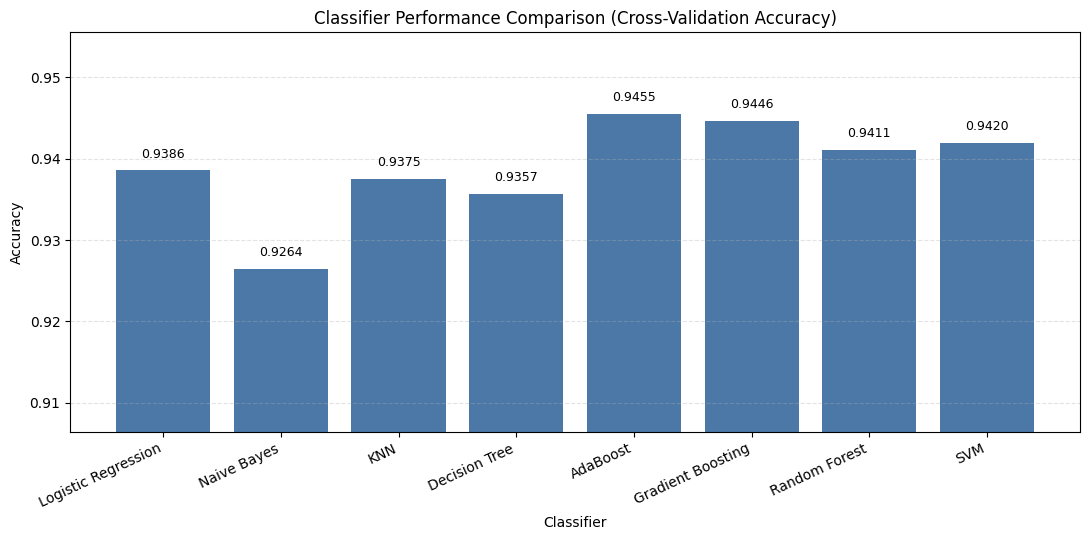

In [60]:
# Cross-validation accuracy comparison across all classifiers.
cvResultsDf = pd.DataFrame({
    "Classifier": [
        "Logistic Regression",
        "Naive Bayes",
        "KNN",
        "Decision Tree",
        "AdaBoost",
        "Gradient Boosting",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        logRAvgAccuracy,
        nbAvgAccuracy,
        knnBestCvAccuracy,
        decisionTreeBestCvAccuracy,
        adaBoostBestCvAccuracy,
        gradientBoostBestCvAccuracy,
        randomForestBestCvAccuracy,
        svmBestCvAccuracy
    ]
})

plt.figure(figsize=(11, 5.5))
ax = plt.gca()
ax.bar(cvResultsDf["Classifier"], cvResultsDf["Accuracy"], color="#4c78a8")
ax.set_title("Classifier Performance Comparison (Cross-Validation Accuracy)")
ax.set_xlabel("Classifier")
ax.set_ylabel("Accuracy")
ax.set_ylim(max(0.0, cvResultsDf["Accuracy"].min() - 0.02), cvResultsDf["Accuracy"].max() + 0.01)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.xticks(rotation=25, ha="right")
add_value_labels(ax)
plt.tight_layout()
plt.show()


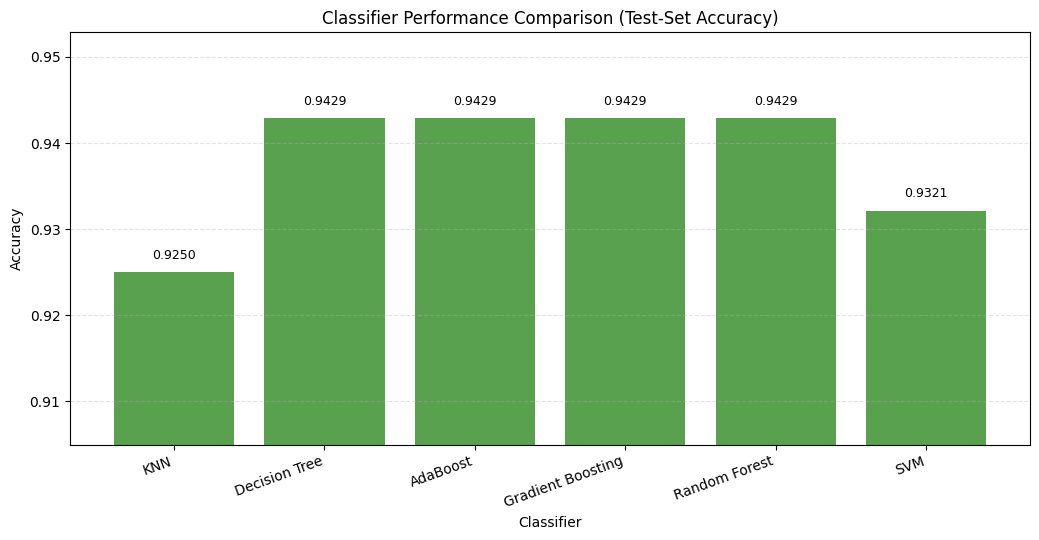

In [61]:
# Held-out test accuracy comparison for the tuned Part 2 classifiers.
testResultsDf = pd.DataFrame({
    "Classifier": [
        "KNN",
        "Decision Tree",
        "AdaBoost",
        "Gradient Boosting",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        knnTestAccuracy,
        decisionTreeTestAccuracy,
        adaBoostTestAccuracy,
        gradientBoostTestAccuracy,
        randomForestTestAccuracy,
        svmTestAccuracy
    ]
})

plt.figure(figsize=(10.5, 5.5))
ax = plt.gca()
ax.bar(testResultsDf["Classifier"], testResultsDf["Accuracy"], color="#59a14f")
ax.set_title("Classifier Performance Comparison (Test-Set Accuracy)")
ax.set_xlabel("Classifier")
ax.set_ylabel("Accuracy")
ax.set_ylim(max(0.0, testResultsDf["Accuracy"].min() - 0.02), testResultsDf["Accuracy"].max() + 0.01)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.xticks(rotation=20, ha="right")
add_value_labels(ax)
plt.tight_layout()
plt.show()


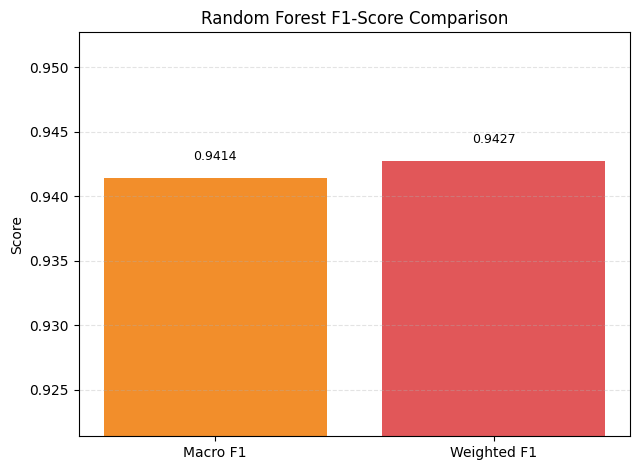

In [62]:
# Random Forest F1-score comparison, if the required metrics are available.
if "randomForestMacroF1" in globals() and "randomForestWeightedF1" in globals():
    rfF1Df = pd.DataFrame({
        "Metric": ["Macro F1", "Weighted F1"],
        "Score": [randomForestMacroF1, randomForestWeightedF1]
    })

    plt.figure(figsize=(6.5, 4.8))
    ax = plt.gca()
    ax.bar(rfF1Df["Metric"], rfF1Df["Score"], color=["#f28e2b", "#e15759"])
    ax.set_title("Random Forest F1-Score Comparison")
    ax.set_ylabel("Score")
    ax.set_ylim(max(0.0, rfF1Df["Score"].min() - 0.02), rfF1Df["Score"].max() + 0.01)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    add_value_labels(ax)
    plt.tight_layout()
    plt.show()
else:
    # Skip gracefully if these Random Forest F1 metrics are unavailable in another notebook version.
    pass


In this comparison, tuned tree-based and boosting methods achieve the strongest test accuracy, while KNN and SVM are slightly lower on the same split. Cross-validation and test-set values are broadly consistent, indicating stable generalization under the selected preprocessing and evaluation protocol.


### Test your code

`test-before.csv` is retained only as a local runnability check before submission.
Final reported assignment results in this notebook are based on `rice-final2.csv`; external-test outputs should be cleared in the polished submission notebook.


In [63]:
# Load the test dataset to test out your model (positional-alignment-v2)
testFileName = "test-before.csv"
testPath = Path(testFileName)

if not testPath.exists():
    raise FileNotFoundError(f"External test dataset not found: {testPath.resolve()}")

testDf = pd.read_csv(testPath, na_values="?")
if testDf.shape[1] < 2:
    raise ValueError("External dataset must contain at least one feature column and one class column.")

xExternalRaw = testDf.iloc[:, :-1].copy()
yExternalRaw = testDf.iloc[:, -1].copy()

labelMap = {"class1": 0, "class2": 1}
yExternalClean = yExternalRaw.astype(str).str.strip()
yExternal = yExternalClean.map(labelMap)

if yExternal.isnull().any():
    unknownLabels = sorted(yExternalClean[yExternal.isnull()].unique())
    raise ValueError(f"Unexpected external class labels found: {unknownLabels}")

yExternal = yExternal.astype(int).to_numpy()

trainingFeatureNames = list(X.columns)
externalFeatureNames = list(xExternalRaw.columns)

print("External test dataset loaded successfully.")
print(f"Dataset shape: {testDf.shape}")
print(f"Feature matrix shape: {xExternalRaw.shape}")
print(f"Target vector shape: {yExternal.shape}")
print(f"Training feature names ({len(trainingFeatureNames)}): {trainingFeatureNames}")
print(f"External feature names ({len(externalFeatureNames)}): {externalFeatureNames}")
print("Using positional feature alignment based on repository column order.")

if len(externalFeatureNames) > len(trainingFeatureNames):
    raise ValueError(
        "Positional alignment is impossible because the external set has more features "
        f"({len(externalFeatureNames)}) than the training set ({len(trainingFeatureNames)})."
    )

alignedFeatureSpace = trainingFeatureNames[:len(externalFeatureNames)]
print(f"Final aligned feature space ({len(alignedFeatureSpace)}): {alignedFeatureSpace}")

xTrainAlignedRaw = X.loc[:, alignedFeatureSpace].copy()
xExternalAlignedRaw = xExternalRaw.copy()
xExternalAlignedRaw.columns = alignedFeatureSpace

xTrainAlignedRaw = xTrainAlignedRaw.apply(pd.to_numeric, errors="coerce")
xExternalAlignedRaw = xExternalAlignedRaw.apply(pd.to_numeric, errors="coerce")

fullyMissingTrainColumns = xTrainAlignedRaw.columns[xTrainAlignedRaw.isna().all()].tolist()
if fullyMissingTrainColumns:
    raise ValueError(f"Aligned training columns are fully missing: {fullyMissingTrainColumns}")

fullyMissingExternalColumns = xExternalAlignedRaw.columns[xExternalAlignedRaw.isna().all()].tolist()
if fullyMissingExternalColumns:
    raise ValueError(f"Aligned external columns are fully missing: {fullyMissingExternalColumns}")

# Fit preprocessing on the aligned training representation only.
alignedImputer = SimpleImputer(strategy="mean")
xTrainAlignedImputed = alignedImputer.fit_transform(xTrainAlignedRaw)
xExternalAlignedImputed = alignedImputer.transform(xExternalAlignedRaw)

alignedScaler = MinMaxScaler()
xTrainAlignedScaled = alignedScaler.fit_transform(xTrainAlignedImputed)
xExternalAlignedScaled = alignedScaler.transform(xExternalAlignedImputed)

knnParams = {"n_neighbors": knnBestK, "p": knnBestP}
decisionTreeParams = {
    "max_depth": decisionTreeBestMaxDepth,
    "min_samples_split": decisionTreeBestMinSamplesSplit,
    "min_samples_leaf": decisionTreeBestMinSamplesLeaf,
}
adaBoostParams = {
    "n_estimators": adaBoostBestNEstimators,
    "learning_rate": adaBoostBestLearningRate,
}
gradientBoostParams = {
    "max_depth": gradientBoostBestMaxDepth,
    "n_estimators": gradientBoostBestNEstimators,
    "learning_rate": gradientBoostBestLearningRate,
}
rfParams = {
    "n_estimators": randomForestBestNEstimators,
    "max_leaf_nodes": randomForestBestMaxLeafNodes,
    "criterion": "entropy",
    "max_features": "sqrt",
    "random_state": 0,
}
svmParams = {"C": svmBestC, "gamma": svmBestGamma, "kernel": svmBestKernel}

# Fit final models on the aligned training representation.
allModels = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=0).fit(xTrainAlignedScaled, yProcessed),
    "Naive Bayes": GaussianNB().fit(xTrainAlignedScaled, yProcessed),
    "KNN": KNeighborsClassifier(metric="minkowski", **knnParams).fit(xTrainAlignedScaled, yProcessed),
    "Decision Tree": DecisionTreeClassifier(random_state=0, **decisionTreeParams).fit(xTrainAlignedScaled, yProcessed),
    "AdaBoost": AdaBoostClassifier(random_state=0, **adaBoostParams).fit(xTrainAlignedScaled, yProcessed),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0, **gradientBoostParams).fit(xTrainAlignedScaled, yProcessed),
    "Random Forest": RandomForestClassifier(**rfParams).fit(xTrainAlignedScaled, yProcessed),
    "SVM": SVC(random_state=0, **svmParams).fit(xTrainAlignedScaled, yProcessed)
}

print()
print("External test results on test-before.csv")
print("-" * 60)

for modelName, model in allModels.items():
    yExternalPred = model.predict(xExternalAlignedScaled)

    externalAccuracy = accuracy_score(yExternal, yExternalPred)
    externalMacroF1 = f1_score(yExternal, yExternalPred, average="macro")
    externalWeightedF1 = f1_score(yExternal, yExternalPred, average="weighted")

    print(f"{modelName} external test accuracy: {externalAccuracy:.4f}")
    print(f"{modelName} external test macro average F1: {externalMacroF1:.4f}")
    print(f"{modelName} external test weighted average F1: {externalWeightedF1:.4f}")
    print()


External test dataset loaded successfully.
Dataset shape: (209, 7)
Feature matrix shape: (209, 6)
Target vector shape: (209,)
Training feature names (7): ['Area', 'Perimiter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent']
External feature names (6): ['a1', 'a2', 'a3', 'a4', 'a5', 'a6']
Using positional feature alignment based on repository column order.
Final aligned feature space (6): ['Area', 'Perimiter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area']

External test results on test-before.csv
------------------------------------------------------------
Logistic Regression external test accuracy: 0.6555
Logistic Regression external test macro average F1: 0.6076
Logistic Regression external test weighted average F1: 0.6293

Naive Bayes external test accuracy: 0.5789
Naive Bayes external test macro average F1: 0.3667
Naive Bayes external test weighted average F1: 0.4246

KNN external test accuracy: 0.5933
KNN external test m

## **3. Reflection and Discussion**


### Reflection and Discussion

1. **Comparison of model performance and possible algorithmic explanations**

   Although the performance differences across classifiers were not large, the results still suggest meaningful differences in how well each algorithm matches the structure of this task. Simpler models such as **Logistic Regression** remained highly competitive, which indicates that the two rice classes are already reasonably separable after preprocessing and that the decision boundary is not extremely complex. By contrast, **Naive Bayes** was slightly weaker, which is consistent with its strong conditional independence assumption, since the image-derived grain features are likely to be correlated. Among the nonlinear methods, **tree-based** and **kernel-based** models performed strongly because they are better able to capture feature interactions and nonlinearity. In particular, the strong results of **Gradient Boosting**, **Random Forest**, and **SVM** are consistent with their algorithmic design: boosting improves performance by correcting previous errors sequentially, random forests reduce variance through aggregation, and SVM can model flexible class boundaries through the kernel trick.


2. **Data leakage issue and how it was resolved**

   During review of the workflow, we identified a potential **data leakage** issue in the preprocessing stage. The original logic fitted the imputer and scaler on the full dataset before cross-validation and before the train/test split, which means that information from validation folds or the test set could influence the preprocessing parameters. Although this issue had only a small numerical effect on this dataset, it is methodologically unsound because evaluation should simulate unseen data as fairly as possible. To address this, we retained the separate preprocessing block only for the assignment-required preview of the processed dataset, while in **Part 1** and **Part 2** we moved imputation and scaling inside `Pipeline`. This ensures that preprocessing is fitted only on the training portion within each fold or split, making the evaluation procedure more rigorous and better aligned with good machine learning practice.

3. **Potential in ensemble model and hyperparameter tuning**

   The results suggest that **ensemble methods** are useful on this dataset, but their advantage is modest rather than dramatic. Both **Gradient Boosting** and **Random Forest** achieved strong performance, which supports the idea that combining multiple weak or unstable learners can improve robustness and generalization. At the same time, several tuned hyperparameters were selected on the boundaries of the search grids, which indicates that broader search ranges could still be explored. However, this does not imply that the current tuning was ineffective. Rather, it suggests that the existing ranges were sufficient to identify strong-performing configurations for the assignment, while any additional gain from wider search would likely be small relative to the extra computational cost. In this sense, the present tuning strategy is reasonable from an **efficiency** perspective: it captures most of the available performance improvement without requiring unnecessarily large parameter searches.
